In [ ]:
!pip -q install nltk

In [ ]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import files

uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

print("Dataset file:", DATA_PATH)

Saving vast_english_french.txt to vast_english_french (1).txt
Dataset file: vast_english_french (1).txt


In [ ]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?¿¡,;:])", r" \1 ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9.!?¿¡,;:'’\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def read_pairs(path):
    pairs = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if "\t" in line:
                parts = line.split("\t")
            elif "|||" in line:
                parts = line.split("|||")
            elif "," in line:
                parts = line.split(",", 1)
            else:
                continue

            if len(parts) >= 2:
                english = normalize_text(parts[0])
                french = normalize_text(parts[1])

                if english and french:
                    pairs.append((english, french))

    return pairs


pairs = read_pairs(DATA_PATH)

print("Total sentence pairs:", len(pairs))
print("\nSample pairs:")
for i in range(5):
    print(pairs[i])

Total sentence pairs: 555

Sample pairs:
('i am cold', "j'ai froid")
('you are tired', 'tu es fatigué')
('he is hungry', 'il a faim')
('she is happy', 'elle est heureuse')
('we are friends', 'nous sommes amis')


In [ ]:
MAX_TOKENS = 30

filtered_pairs = []

for eng, fr in pairs:
    if len(eng.split()) <= MAX_TOKENS and len(fr.split()) <= MAX_TOKENS:
        filtered_pairs.append((eng, fr))

pairs = filtered_pairs

print("Pairs after filtering:", len(pairs))

Pairs after filtering: 555


In [ ]:
random.shuffle(pairs)

split_index = int(0.8 * len(pairs))

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Training pairs: 444
Validation pairs: 111


In [ ]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


class Vocab:
    def __init__(self, sentences, min_freq=1):
        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        counter = Counter()

        for sentence in sentences:
            counter.update(sentence.split())

        for token, count in counter.most_common():
            if count >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def encode(self, sentence, add_sos=False, add_eos=True):
        tokens = sentence.split()
        ids = []

        if add_sos:
            ids.append(SOS_IDX)

        ids.extend([self.stoi.get(tok, UNK_IDX) for tok in tokens])

        if add_eos:
            ids.append(EOS_IDX)

        return ids

    def decode(self, ids):
        tokens = []

        for idx in ids:
            token = self.itos[int(idx)]

            if token == EOS_TOKEN:
                break

            if token not in [PAD_TOKEN, SOS_TOKEN]:
                tokens.append(token)

        return tokens


src_vocab = Vocab([eng for eng, fr in train_pairs])
tgt_vocab = Vocab([fr for eng, fr in train_pairs])

print("English vocab size:", len(src_vocab))
print("French vocab size:", len(tgt_vocab))

English vocab size: 897
French vocab size: 995


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        src_text, tgt_text = self.pairs[index]

        src_ids = self.src_vocab.encode(src_text, add_sos=False, add_eos=True)
        tgt_ids = self.tgt_vocab.encode(tgt_text, add_sos=True, add_eos=True)

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_batch(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)

    return src_batch, tgt_batch


BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[1]

        hidden_last = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(torch.cat((hidden_last, encoder_outputs), dim=2))
        )

        attention_scores = self.v(energy).squeeze(2)

        attention_scores = attention_scores.masked_fill(mask == 0, -1e10)

        attention_weights = torch.softmax(attention_scores, dim=1)

        return attention_weights

In [ ]:
class AttentionEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        encoder_outputs, hidden = self.gru(embedded)

        return encoder_outputs, hidden


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(emb_dim + hidden_dim * 2, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))

        attention_weights = self.attention(hidden, encoder_outputs, mask)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        )

        rnn_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(rnn_input, hidden)

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)

        prediction = self.fc_out(
            torch.cat((output, context, embedded), dim=1)
        )

        return prediction, hidden, attention_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return src != PAD_IDX

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]
        src_len = src.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src_len).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        input_token = tgt[:, 0]

        mask = self.create_mask(src)

        for t in range(1, tgt_len):
            prediction, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            outputs[:, t, :] = prediction
            attentions[:, t, :] = attention_weights

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs, attentions

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.3

attention = Attention(HIDDEN_DIM)

attention_encoder = AttentionEncoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

attention_decoder = AttentionDecoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention
)

attention_model = Seq2SeqAttention(
    attention_encoder,
    attention_decoder,
    device
).to(device)

attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("Problem 2 Attention Model Parameters:", count_parameters(attention_model))

Problem 2 Attention Model Parameters: 5436131


In [ ]:
def train_one_epoch_attention(model, loader, optimizer, criterion, clip=1.0):
    model.train()

    epoch_loss = 0

    for src, tgt in tqdm(loader, desc="Training Attention", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output, _ = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]

        output = output[:, 1:, :].contiguous().view(-1, output_dim)
        tgt = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(output, tgt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_loss_attention(model, loader, criterion):
    model.eval()

    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in tqdm(loader, desc="Validation Attention", leave=False):
            src = src.to(device)
            tgt = tgt.to(device)

            output, _ = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].contiguous().view(-1, output_dim)
            tgt = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
EPOCHS_ATTENTION = 20

attention_train_losses = []
attention_val_losses = []

for epoch in range(EPOCHS_ATTENTION):
    train_loss = train_one_epoch_attention(
        attention_model,
        train_loader,
        attention_optimizer,
        criterion
    )

    val_loss = evaluate_loss_attention(
        attention_model,
        val_loader,
        criterion
    )

    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02}/{EPOCHS_ATTENTION}")
    print(f"Attention Training Loss:   {train_loss:.4f}")
    print(f"Attention Validation Loss: {val_loss:.4f}")
    print()

Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/20
Attention Training Loss:   6.3710
Attention Validation Loss: 6.4863



Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20
Attention Training Loss:   0.2675
Attention Validation Loss: 5.7761



Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20
Attention Training Loss:   0.2010
Attention Validation Loss: 5.7968



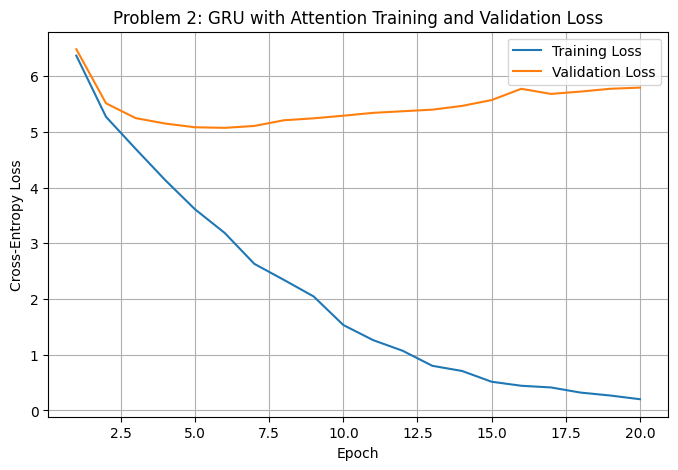

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(attention_train_losses) + 1),
    attention_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(attention_val_losses) + 1),
    attention_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 2: GRU with Attention Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("problem2_attention_gru_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
def translate_sentence_attention(model, sentence, src_vocab, tgt_vocab, max_len=30):
    model.eval()

    sentence = normalize_text(sentence)

    src_tokens = sentence.split()
    src_ids = src_vocab.encode(sentence, add_sos=False, add_eos=True)

    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(device)

    predicted_ids = []
    attention_list = []

    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden, attention_weights = model.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

        top1 = prediction.argmax(1).item()

        if top1 == EOS_IDX:
            break

        predicted_ids.append(top1)
        attention_list.append(attention_weights.squeeze(0).cpu().numpy())

        input_token = torch.tensor([top1], dtype=torch.long).to(device)

    predicted_tokens = tgt_vocab.decode(predicted_ids)

    return predicted_tokens, attention_list, src_tokens

In [ ]:
def evaluate_translation_metrics_attention(model, pairs, src_vocab, tgt_vocab, max_len=30, limit=None):
    model.eval()

    smooth = SmoothingFunction().method1

    exact_matches = 0
    references = []
    hypotheses = []

    selected_pairs = pairs if limit is None else pairs[:limit]

    sample_rows = []

    for src_text, tgt_text in tqdm(selected_pairs, desc="Evaluating Attention Translations"):
        pred_tokens, _, _ = translate_sentence_attention(
            model,
            src_text,
            src_vocab,
            tgt_vocab,
            max_len=max_len
        )

        target_tokens = tgt_text.split()

        exact_match = pred_tokens == target_tokens

        if exact_match:
            exact_matches += 1

        references.append([target_tokens])
        hypotheses.append(pred_tokens)

        sent_bleu = sentence_bleu(
            [target_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        if len(sample_rows) < 5:
            sample_rows.append({
                "English Input": src_text,
                "Target French": tgt_text,
                "Predicted French": " ".join(pred_tokens),
                "Exact Match": exact_match,
                "Sentence BLEU-4": round(sent_bleu, 4)
            })

    sequence_accuracy = exact_matches / len(selected_pairs)

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return sequence_accuracy, bleu4, sample_rows

In [ ]:
attention_sequence_accuracy, attention_bleu4, attention_sample_rows = evaluate_translation_metrics_attention(
    attention_model,
    val_pairs,
    src_vocab,
    tgt_vocab,
    max_len=30,
    limit=None
)

print("Problem 2 Results")
print("-----------------")
print(f"Validation Exact Sequence Accuracy: {attention_sequence_accuracy:.4f}")
print(f"Validation BLEU-4 Score: {attention_bleu4:.4f}")
print(f"Final Validation Loss: {attention_val_losses[-1]:.4f}")

Evaluating Attention Translations:   0%|          | 0/111 [00:00<?, ?it/s]

Problem 2 Results
-----------------
Validation Exact Sequence Accuracy: 0.0000
Validation BLEU-4 Score: 0.1181
Final Validation Loss: 5.7968


In [ ]:
attention_sample_df = pd.DataFrame(attention_sample_rows)
attention_sample_df

,English Input,Target French,Predicted French,Exact Match,Sentence BLEU-4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils nourrissent les oiseaux dans le parc,False,0.1635
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle boit du violon tous les matins,False,0.1757
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'aime vraiment marcher dans la forêt dense,False,0.1757
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle adore porter des vestes en cuir modernes,False,0.5411
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le bus arrive un grand de banlieusards,False,0.0541


In [ ]:
attention_sample_df.to_csv("problem2_attention_sample_translations.csv", index=False)

In [ ]:
def plot_attention_map(model, sentence, src_vocab, tgt_vocab, save_name="problem2_attention_map.png"):
    predicted_tokens, attention_list, src_tokens = translate_sentence_attention(
        model,
        sentence,
        src_vocab,
        tgt_vocab,
        max_len=30
    )

    if len(attention_list) == 0:
        print("No attention weights to plot.")
        return

    src_tokens_with_eos = src_tokens + [EOS_TOKEN]

    attention_matrix = np.array(attention_list)

    plt.figure(figsize=(10, 6))
    plt.imshow(attention_matrix, aspect="auto")

    plt.xticks(
        ticks=np.arange(len(src_tokens_with_eos)),
        labels=src_tokens_with_eos,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(predicted_tokens)),
        labels=predicted_tokens
    )

    plt.xlabel("English Source Tokens")
    plt.ylabel("Predicted French Tokens")
    plt.title("Problem 2 Attention Map")
    plt.colorbar(label="Attention Weight")
    plt.tight_layout()
    plt.savefig(save_name, dpi=200, bbox_inches="tight")
    plt.show()

    print("English input:", sentence)
    print("Predicted French:", " ".join(predicted_tokens))

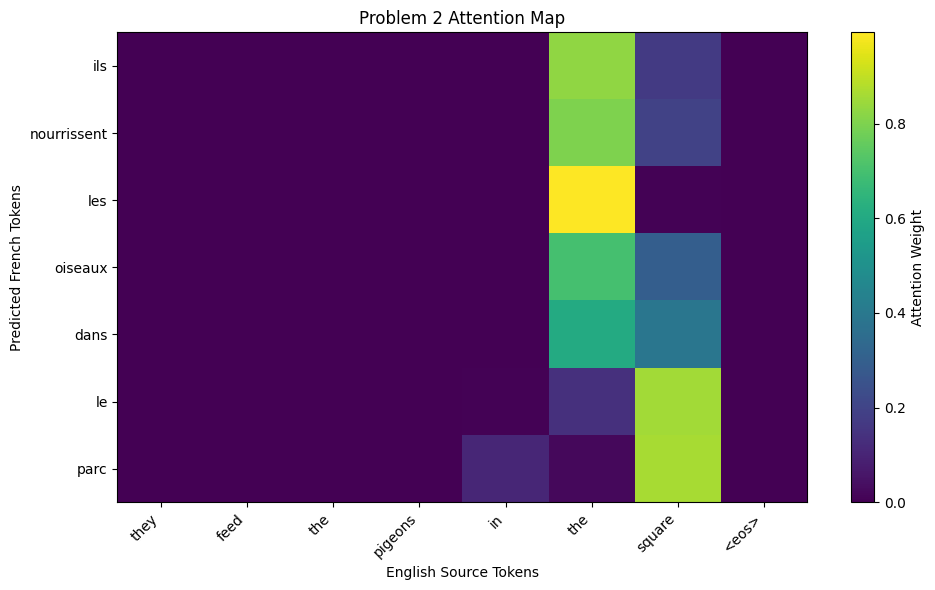

English input: they feed the pigeons in the square
Predicted French: ils nourrissent les oiseaux dans le parc


In [ ]:
example_sentence_1 = val_pairs[0][0]

plot_attention_map(
    attention_model,
    example_sentence_1,
    src_vocab,
    tgt_vocab,
    save_name="problem2_attention_map_1.png"
)

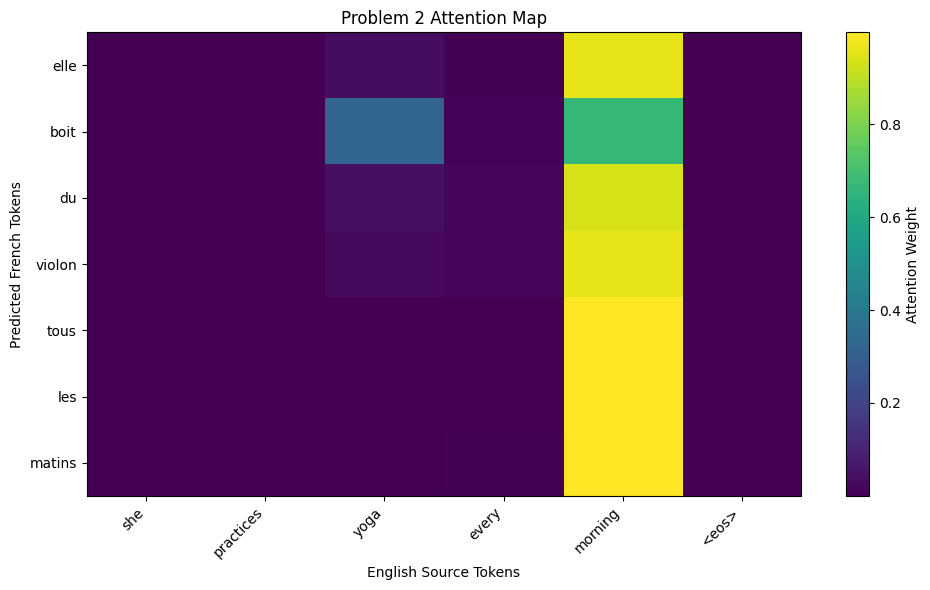

English input: she practices yoga every morning
Predicted French: elle boit du violon tous les matins


In [ ]:
example_sentence_2 = val_pairs[1][0]

plot_attention_map(
    attention_model,
    example_sentence_2,
    src_vocab,
    tgt_vocab,
    save_name="problem2_attention_map_2.png"
)

In [ ]:
problem1_final_val_loss = 0.0000      # Replace with Problem 1 final validation loss
problem1_exact_accuracy = 0.0000      # Replace with Problem 1 exact sequence accuracy
problem1_bleu4 = 0.0000               # Replace with Problem 1 BLEU-4 score

comparison_df = pd.DataFrame({
    "Model": ["Baseline GRU", "GRU with Attention"],
    "Final Validation Loss": [problem1_final_val_loss, attention_val_losses[-1]],
    "Exact Sequence Accuracy": [problem1_exact_accuracy, attention_sequence_accuracy],
    "Validation BLEU-4": [problem1_bleu4, attention_bleu4]
})

comparison_df

,Model,Final Validation Loss,Exact Sequence Accuracy,Validation BLEU-4
0,Baseline GRU,0.000000,0.0,0.000000
1,GRU with Attention,5.796754,0.0,0.118099


In [ ]:
comparison_df.to_csv("problem1_vs_problem2_comparison.csv", index=False)